In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn .metrics import mean_squared_error , r2_score, mean_absolute_error
from sklearn .model_selection import train_test_split

In [2]:
from google.colab import files
data =files.upload()

Saving fitness_tracker_dataset (1).xlsx to fitness_tracker_dataset (1).xlsx


In [3]:
df=pd.read_excel('fitness_tracker_dataset (1).xlsx')

In [4]:
df.head()

,Session_ID,Workout_Type,Experience_Level,Age,Duration_Mins,Avg_Heart_Rate,Max_Heart_Rate,Peak_Exertion_BPM,Calories_Burned
0,SES_0000,HIIT,Beginner,31,82,117,145,146,881.14
1,SES_0001,Yoga,Beginner,54,36,152,177,176,616.81
2,SES_0002,Running,Intermediate,38,52,121,146,144,725.31
3,SES_0003,HIIT,Advanced,35,48,110,142,141,636.35
4,SES_0004,HIIT,Advanced,22,32,129,161,159,610.45


`cleaning / preprocessing `

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Session_ID         1000 non-null   object 
 1   Workout_Type       1000 non-null   object 
 2   Experience_Level   1000 non-null   object 
 3   Age                1000 non-null   int64  
 4   Duration_Mins      1000 non-null   int64  
 5   Avg_Heart_Rate     1000 non-null   int64  
 6   Max_Heart_Rate     1000 non-null   int64  
 7   Peak_Exertion_BPM  1000 non-null   int64  
 8   Calories_Burned    1000 non-null   float64
dtypes: float64(1), int64(5), object(3)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Age,Duration_Mins,Avg_Heart_Rate,Max_Heart_Rate,Peak_Exertion_BPM,Calories_Burned
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,38.823000,53.851000,134.448000,159.450000,158.790000,745.361570
std,12.035968,20.251146,14.434322,15.467927,16.281123,155.307284
min,18.000000,20.000000,110.000000,126.000000,120.000000,417.300000
25%,28.000000,36.000000,122.000000,147.000000,146.000000,613.287500
50%,39.000000,54.000000,134.000000,159.000000,158.500000,748.350000
75%,50.000000,72.000000,147.000000,172.000000,171.000000,874.420000
max,59.000000,89.000000,159.000000,193.000000,199.000000,1068.200000


`eda`

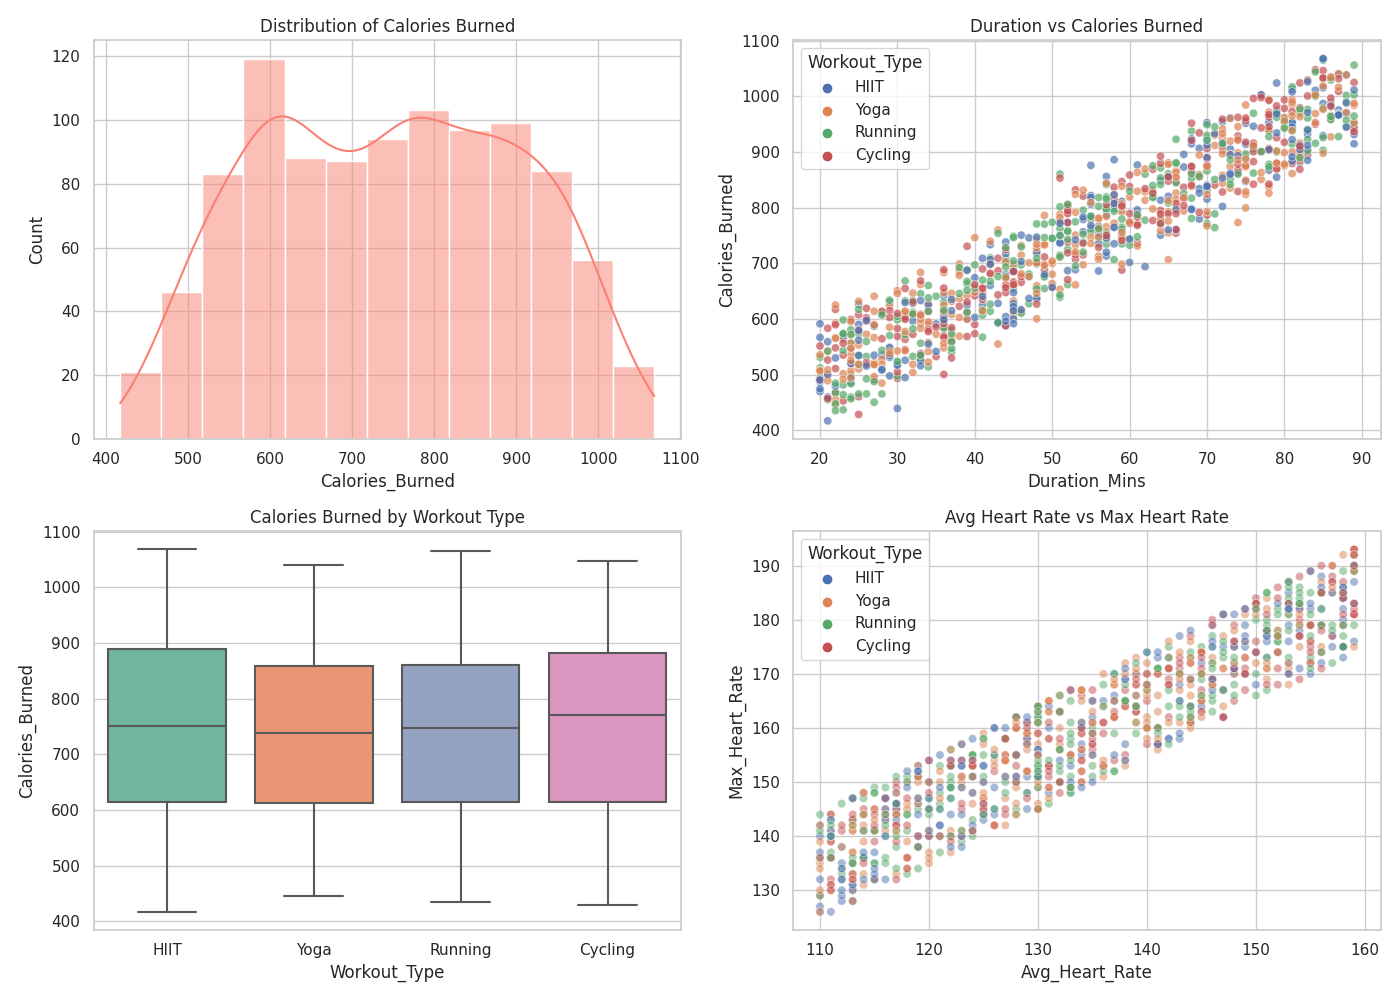

`feature engineering `
- drop the id column
-  drop session id (feature extraction although by boxplot we analyse that type of workout dosenot effect more to calories but i think we should kept this column )

- use standard scalar to standarize

- convert categorical to numerical (workout type (one hot encoding), experience (ordinal encoding),

- use pca as avg ,max and and exertion col give the same info in different word so our model get confuse to give credit to which col coeeficient become unstable and unpredictable

In [7]:
df_copy=df.copy()

In [8]:
#dropiing unnecessary column
df_copy=df_copy.drop(columns=['Session_ID'])

In [9]:
#one hot encoding
df_copy=pd.get_dummies(df_copy,columns=['Workout_Type'],dtype=int,drop_first=True)

In [10]:
# ordinal encoding
experience={'Beginner': 0, 'Intermediate': 1, 'Advanced': 2}
df_copy['Experience_Level']=df_copy['Experience_Level'].map(experience)

In [11]:
#ordinal encoding
df_copy.sample(5)

,Experience_Level,Age,Duration_Mins,Avg_Heart_Rate,Max_Heart_Rate,Peak_Exertion_BPM,Calories_Burned,Workout_Type_HIIT,Workout_Type_Running,Workout_Type_Yoga
165,0,38,71,112,134,130,850.79,0,1,0
28,0,34,40,138,153,154,659.02,0,0,1
384,2,45,48,125,155,157,699.66,0,1,0
973,0,39,60,118,149,153,743.96,1,0,0
785,2,38,25,117,140,143,518.03,0,1,0


In [12]:
#pca
heart=['Avg_Heart_Rate', 'Max_Heart_Rate', 'Peak_Exertion_BPM']
pca=PCA(n_components=1)
df_copy['heart_rate']=pca.fit_transform(df_copy[heart])


In [13]:
#dropping previous heart rate column
df_copy=df_copy.drop(columns=heart)

In [14]:
df_copy.sample(5)

,Experience_Level,Age,Duration_Mins,Calories_Burned,Workout_Type_HIIT,Workout_Type_Running,Workout_Type_Yoga,heart_rate
127,1,38,20,512.29,0,1,0,-5.292553
120,1,36,66,866.81,0,0,1,13.060803
918,2,51,72,933.67,0,0,1,39.101524
500,2,22,25,590.62,1,0,0,42.082632
932,2,32,80,942.80,0,1,0,11.411443


In [15]:
#stadarize the value
numeric_feature =['Age', 'Duration_Mins', 'heart_rate']
scaler=StandardScaler()
df_copy[numeric_feature]=scaler.fit_transform(df_copy[numeric_feature])

`model training`

In [16]:
X=df_copy.drop(columns=['Calories_Burned'])
y=df_copy['Calories_Burned']


In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,y ,test_size=0.2,random_state=42)

In [18]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [19]:
y_pred=model.predict(X_test)

In [24]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
mse = mean_squared_error(y_test, y_pred)

In [25]:
print("--- Model Training Successful! ---")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} calories")
print(f"R-squared (R²) Score: {r2:.4f} ({r2*100:.1f}% of variance explained)")
print(f"Mean Squared Error (MSE): {mse:.2f}")

--- Model Training Successful! ---
Root Mean Squared Error (RMSE): 25.04 calories
R-squared (R²) Score: 0.9746 (97.5% of variance explained)
Mean Squared Error (MSE): 627.05


In [ ]:
# Create a dataframe to store features and their corresponding weights
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (Weight)': model.coef_
})

# Sort by the absolute impact so the heaviest drivers are at the top
coefficients['Absolute_Impact'] = coefficients['Coefficient (Weight)'].abs()
coefficients = coefficients.sort_values(by='Absolute_Impact', ascending=False).drop(columns=['Absolute_Impact'])

print(f"Base Intercept: {model.intercept_:.2f} calories\n")
print("--- Feature Coefficients ---")
print(coefficients.to_string(index=False))

Base Intercept: 744.25 calories

--- Feature Coefficients ---
             Feature  Coefficient (Weight)
       Duration_Mins            145.989229
          heart_rate             40.159793
                 Age             -5.089896
    Experience_Level              1.979209
   Workout_Type_HIIT             -1.449347
   Workout_Type_Yoga             -1.364460
Workout_Type_Running             -0.235349


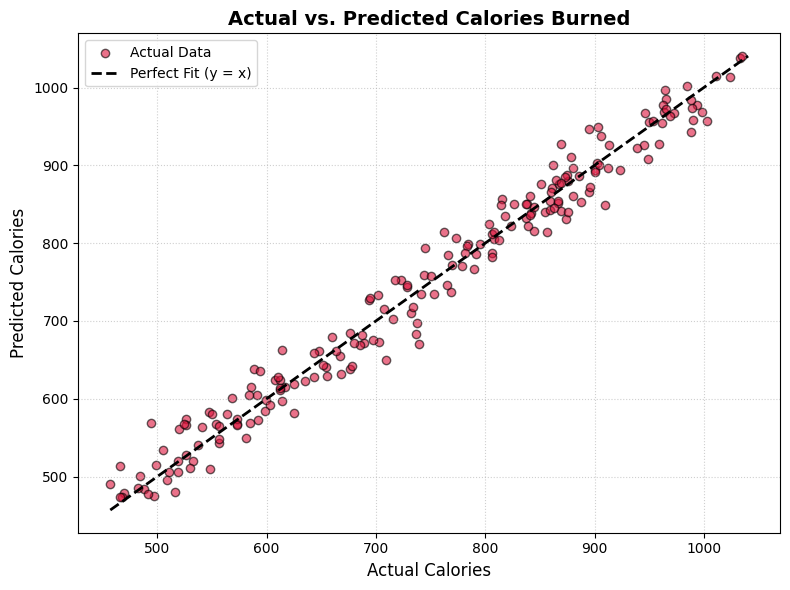

In [26]:
import matplotlib.pyplot as plt

# ==============================================================================
# 4. ACTUAL VS. PREDICTED CALORIES PLOT (LINEAR REGRESSION LINE)
# ==============================================================================
plt.figure(figsize=(8, 6))

# Plot actual vs predicted values
plt.scatter(y_test, y_pred, color='crimson', alpha=0.6, edgecolors='k', label='Actual Data')

# Draw the 1:1 perfect prediction reference line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')

# Labels and Styling
plt.title('Actual vs. Predicted Calories Burned', fontsize=14, fontweight='bold')
plt.xlabel('Actual Calories', fontsize=12)
plt.ylabel('Predicted Calories', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

# giving input and checking result

In [ ]:
import numpy as np

print("🏋️‍♂️ --- Fitness Tracker Calorie Predictor --- 🏋️‍♂️")
print("Please enter the following details:")

# 1. Collect inputs dynamically from the user
new_age = float(input("Enter Age: "))
new_duration = float(input("Enter Workout Duration (in minutes): "))

print("\n--- Experience Levels: 0 for Beginner, 1 for Intermediate, 2 for Advanced ---")
new_experience = int(input("Enter Experience Level (0, 1, or 2): "))

print("\n--- Heart Rate Metrics ---")
avg_hr = float(input("Enter Average Heart Rate: "))
max_hr = float(input("Enter Maximum Heart Rate: "))
peak_bpm = float(input("Enter Peak Exertion BPM: "))
raw_heart = [[avg_hr, max_hr, peak_bpm]]

print("\n--- Workout Types ---")
workout = input("Enter Workout Type (HIIT, Running, Yoga, Cycling): ").strip().capitalize()

# 2. Map the workout type to our dummy switch columns (ignoring Cycling as baseline)
hiit = 1 if workout == "Hiit" else 0
running = 1 if workout == "Running" else 0
yoga = 1 if workout == "Yoga" else 0

# 3. Apply your pre-trained transformations
heart_pca = pca.transform(raw_heart)[0][0]
scaled_nums = scaler.transform([[new_age, new_duration, heart_pca]])[0]

# 4. Arrange in the exact feature sequence and predict
new_features = [[new_experience, scaled_nums[0], scaled_nums[1], hiit, running, yoga, scaled_nums[2]]]
predicted_calories = model.predict(new_features)[0]

print("\n-----------------------------------------")
print(f"🔥 Estimated Calories Burned: {predicted_calories:.2f} kcal")
print("-----------------------------------------")

🏋️‍♂️ --- Fitness Tracker Calorie Predictor --- 🏋️‍♂️
Please enter the following details:
Enter Age: 18
Enter Workout Duration (in minutes): 60

--- Experience Levels: 0 for Beginner, 1 for Intermediate, 2 for Advanced ---
Enter Experience Level (0, 1, or 2): 1

--- Heart Rate Metrics ---
Enter Average Heart Rate: 115
Enter Maximum Heart Rate: 120
Enter Peak Exertion BPM: 125

--- Workout Types ---
Enter Workout Type (HIIT, Running, Yoga, Cycling): yoga

-----------------------------------------
🔥 Estimated Calories Burned: 714.64 kcal
-----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
